# Exercise 1

#### Phytoplankton growth follows an exponential phase, at least for a certain period of time until resources may become limiting or other factors control the Malthusian growth

######  Plotting the pythoplankton growth contains data from a batch experiment conducted by Flynn et al. (1994).

In [7]:
# importing statement 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#Opening dataset files and reading dataset information (fynn)
df = pd.read_csv('HonsUCT_IntroOceMod/data/flynn94.csv')

In [9]:
#Opening first five row to check dataset
df.head()

,time,cells,biovolume,ammonium,cellC,chl-a
0,0.0,0.04,2.0,1.411,0.60,4.0
1,0.5,0.04,2.2,1.400,0.61,3.0
2,1.0,0.04,2.1,1.383,0.58,3.0
3,1.5,0.04,2.1,1.355,NaN,3.0
4,2.0,0.04,2.1,1.355,0.68,3.0


In [ ]:
df.info

In [30]:
# Extract key variables for plotting
time = df['time']
cells = df['cells']
ammonium = df['ammonium']
cell_c = df['cellC']
chl_a = df['chl-a']

#### 1 Plotting exponential growth
The exponential growth is not observed on the initial phase, everything is slowly growing from day 0-5.5 which is relatively constant in cells 0.1 and 0.2, and according to the phase growth graph on number 2 this is defined as the lag phase, where their are adapting to the introduced environement and there is resources available for growth, less competition. The next stage is the exponential phase, there is a drastical increase in the cells with time between days 6.5-15 and the increases from 0.1-1.5, this rapid growth shows that there is no resources limited and there are equally shared, and less resource competition. The last stage is the  stationary phase and this is where the less resources and the resource competion is very high, which indicates that some are out-competing other between day 19-25 and the cell slightly flucuates between 1.9-2 and this normal lead to death phase where the are no resources. Therefore there is an exponential growth observed.

C:\Users\zncnqu001\AppData\Local\Temp\ipykernel_49304\228455650.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


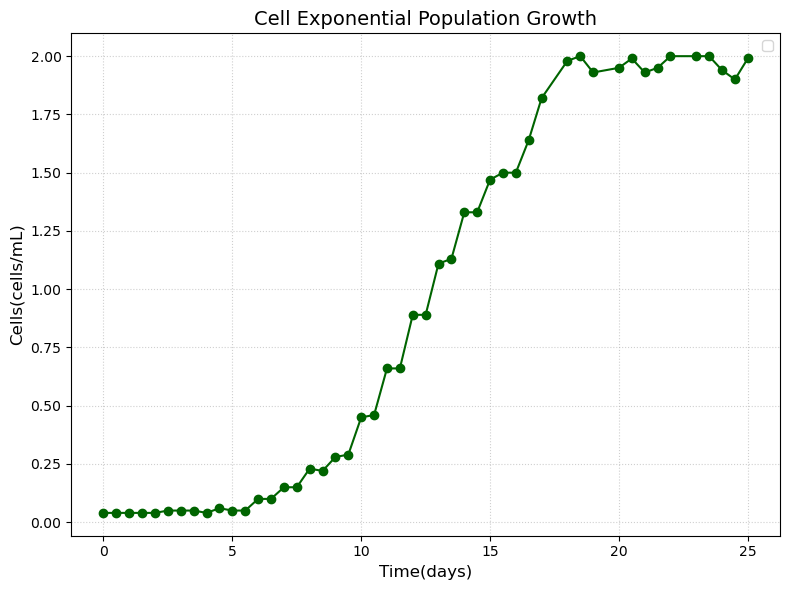

In [47]:
#plotting exponential growth graph
plt.figure(figsize=(8,6))
plt.plot(time, cells,'o-',color='darkgreen')
plt.xlabel('Time(days)', fontsize=12)
plt.ylabel('Cells(cells/mL)', fontsize=12)
plt.title('Cell Exponential Population Growth', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#### 2 Separate the growth curve into some phases

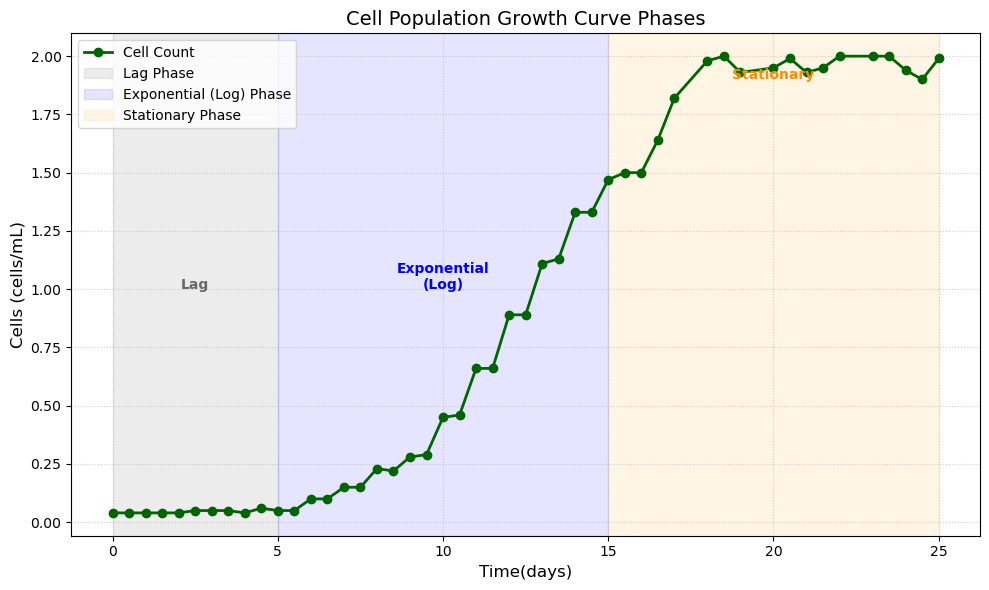

In [48]:
#Define the time boundaries for each phase based
lag_end = 5.0
log_end = 15.0
stationary_end = 25.0

#Plotting the exponential growth graph
plt.figure(figsize=(10, 6))
plt.plot(time, cells, "o-", color="darkgreen", label="Cell Count", linewidth=2)

# Add shaded background regions for each growth phase
plt.axvspan(0, lag_end, color="gray", alpha=0.15, label="Lag Phase")
plt.axvspan(lag_end, log_end, color="blue", alpha=0.1, label="Exponential (Log) Phase")
plt.axvspan(log_end, stationary_end, color="orange", alpha=0.1, label="Stationary Phase")


#  Add text annotations directly inside the graph for clarity
# (I use max(cells) to position the text vertically near the top half)
max_y = max(cells) if len(cells) > 0 else 1
plt.text(lag_end / 2,max_y * 0.5,"Lag",ha="center",fontweight="bold",color="dimgray",)
plt.text((lag_end + log_end) / 2,max_y * 0.5,"Exponential\n(Log)",ha="center",fontweight="bold",color="blue",)
plt.text((log_end + stationary_end) / 2,max_y * 0.95,"Stationary",ha="center",fontweight="bold",color="darkorange",)

# Styling and labels
plt.xlabel("Time(days)", fontsize=12)
plt.ylabel("Cells (cells/mL)", fontsize=12)
plt.title("Cell Population Growth Curve Phases", fontsize=14)
plt.grid(True, linestyle=":", alpha=0.6)

# Reposition legend so it doesn't cover data points
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### 3 Growth expressed in cellular carbon from the onein cell number and chlorophyll

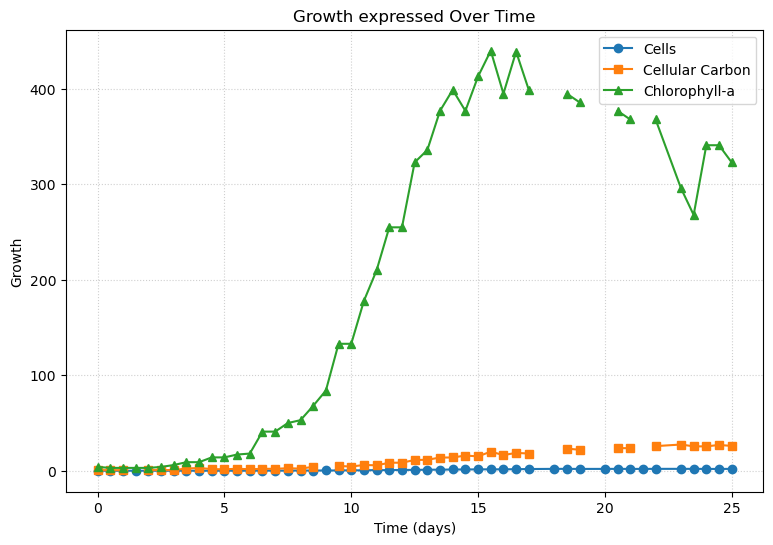

In [42]:
# Extracting the variables from the DataFrame
time = df['time']
cells = df['cells']
cellC = df['cellC']      
chla = df['chl-a'] 

#  Plotting the cells, cellular carbon and chlorophyll-a
plt.figure(figsize=(9, 6))
plt.plot(time, cells, 'o-', label='Cells')
plt.plot(time, cellC, 's-', label='Cellular Carbon')
plt.plot(time, chla, '^-', label='Chlorophyll-a')  # Fixed 'chl-a' issue here too

plt.xlabel('Time (days)')
plt.ylabel('Growth')
plt.title('Growth expressed Over Time')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### 4 Ammonium consumption approximated by an exponential curve
The consumption of ammonium mirrors the exponential growth phase of the phytoplankton. It shows a downcurve of the exponential curve.

C:\Users\zncnqu001\AppData\Local\Temp\ipykernel_49304\1962258496.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


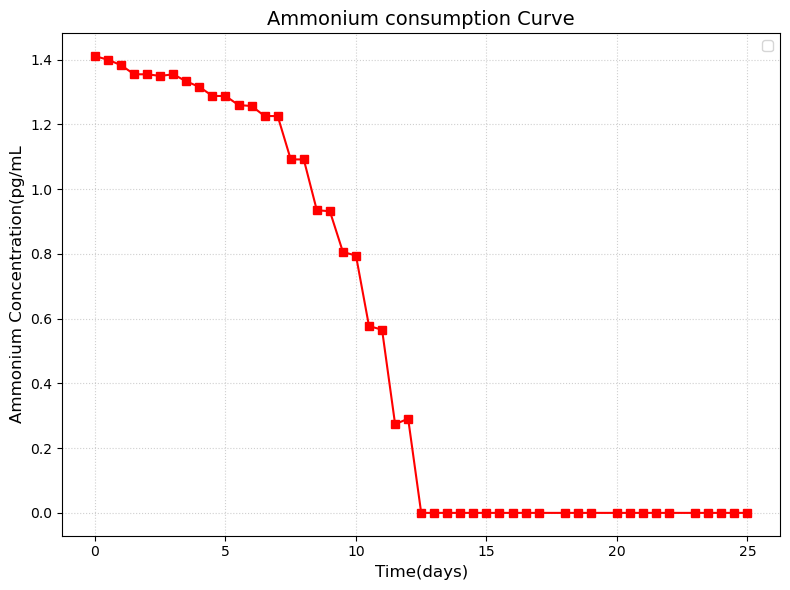

In [50]:
#Plotting ammonium curve

plt.figure(figsize=(8,6))
plt.plot(time, ammonium,'s-',color='red')
plt.xlabel('Time(days)', fontsize=12)
plt.ylabel('Ammonium Concentration(pg/mL', fontsize=12)
plt.title('Ammonium consumption Curve', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Improved plots for question 3 and 4

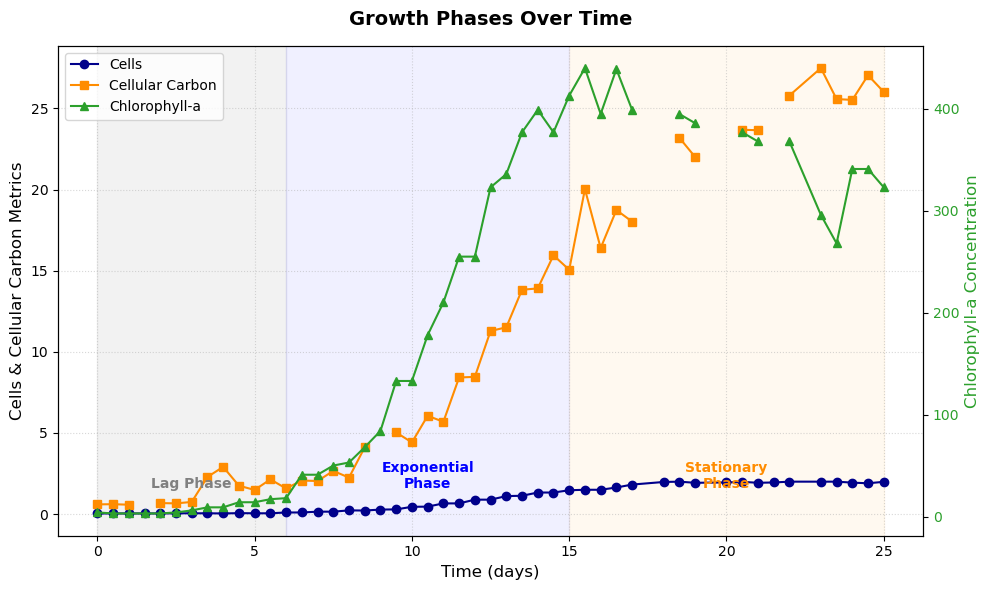

In [46]:
#  Define Phase Boundaries 
lag_end = 6.0
exp_end = 15.0
stat_end = 25.0

# Initialize the Plot with Twin Y-Axes 
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axis 1: Left Y-axis for the smaller metrics (Cells and Cellular Carbon)
color1 = 'tab:blue'
line1 = ax1.plot(time, cells, 'o-', color='darkblue', label='Cells')
line2 = ax1.plot(time, cellC, 's-', color='darkorange', label='Cellular Carbon')
ax1.set_xlabel('Time (days)', fontsize=12)
ax1.set_ylabel('Cells & Cellular Carbon Metrics', fontsize=12)
ax1.tick_params(axis='y')

# Axis 2: Right Y-axis for Chlorophyll-a (the much larger values)
ax2 = ax1.twinx()  
line3 = ax2.plot(time, chla, '^-', color='tab:green', label='Chlorophyll-a')
ax2.set_ylabel('Chlorophyll-a Concentration', color='tab:green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:green')

# --- 3. Add the Growth Phase Shading ---
# We use ax1 for shading so it goes across the background seamlessly
ax1.axvspan(0, lag_end, color='gray', alpha=0.1)
ax1.axvspan(lag_end, exp_end, color='blue', alpha=0.06)
ax1.axvspan(exp_end, stat_end, color='orange', alpha=0.06)

# Add text labels for the phases
ax1.text(lag_end/2, max(cells)*0.8, 'Lag Phase', ha='center', fontweight='bold', color='gray')
ax1.text((lag_end+exp_end)/2, max(cells)*0.8, 'Exponential\nPhase', ha='center', fontweight='bold', color='blue')
ax1.text((exp_end+stat_end)/2, max(cells)*0.8, 'Stationary\nPhase', ha='center', fontweight='bold', color='darkorange')

# --- 4. Combine Legends and Refine Layout ---
# Since we used twin axes, we combine the legends manually so they sit in one box
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

ax1.set_title('Growth Phases Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

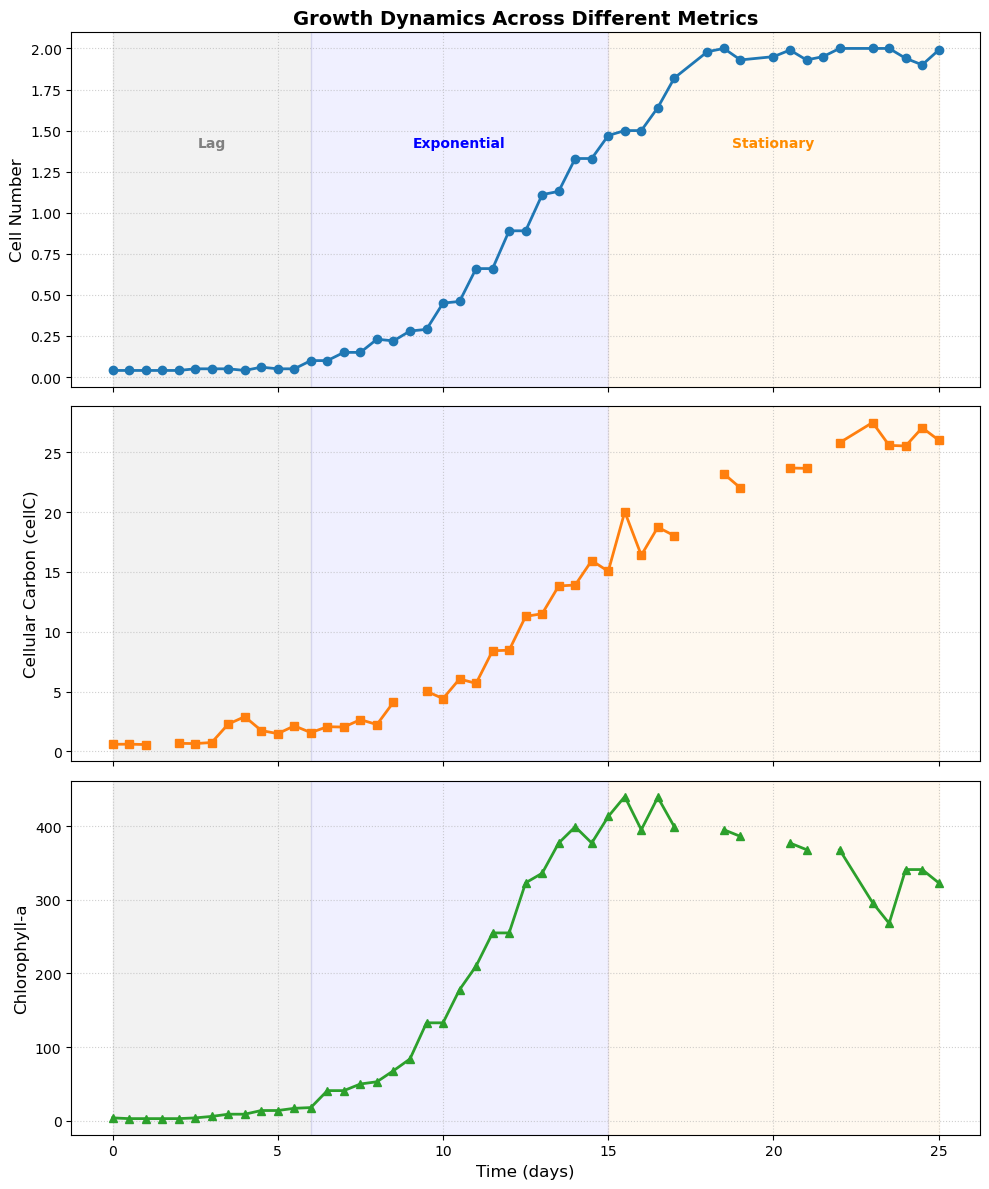

In [49]:


# --- 1. Define Phase Boundaries (Matching your previous timelines) ---
lag_end = 6.0
exp_end = 15.0
stat_end = 25.0

# --- 2. Create a 3-Panel Stacked Plot ---
# nrows=3 means 3 panels vertical, sharex=True locks the time axes together
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

# ---------------- Panel 1: Cell Number ----------------
ax1.plot(time, cells, 'o-', color='tab:blue', linewidth=2, label='Cell Count')
ax1.set_ylabel('Cell Number', fontsize=12)
ax1.set_title('Growth Dynamics Across Different Metrics', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# Shading Phase Blocks for Panel 1
ax1.axvspan(0, lag_end, color='gray', alpha=0.1)
ax1.axvspan(lag_end, exp_end, color='blue', alpha=0.06)
ax1.axvspan(exp_end, stat_end, color='orange', alpha=0.06)
ax1.text(lag_end/2, max(cells)*0.7, 'Lag', ha='center', fontweight='bold', color='gray')
ax1.text((lag_end+exp_end)/2, max(cells)*0.7, 'Exponential', ha='center', fontweight='bold', color='blue')
ax1.text((exp_end+stat_end)/2, max(cells)*0.7, 'Stationary', ha='center', fontweight='bold', color='darkorange')

# ---------------- Panel 2: Cellular Carbon ----------------
# Dropna handles the NaN value present in your row 3 of cellC automatically
ax2.plot(time, cellC, 's-', color='tab:orange', linewidth=2, label='Cellular Carbon')
ax2.set_ylabel('Cellular Carbon (cellC)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# Shading Phase Blocks for Panel 2
ax2.axvspan(0, lag_end, color='gray', alpha=0.1)
ax2.axvspan(lag_end, exp_end, color='blue', alpha=0.06)
ax2.axvspan(exp_end, stat_end, color='orange', alpha=0.06)

# ---------------- Panel 3: Chlorophyll-a ----------------
ax3.plot(time, chla, '^-', color='tab:green', linewidth=2, label='Chlorophyll-a')
ax3.set_ylabel('Chlorophyll-a', fontsize=12)
ax3.set_xlabel('Time (days)', fontsize=12)
ax3.grid(True, linestyle=':', alpha=0.6)

# Shading Phase Blocks for Panel 3
ax3.axvspan(0, lag_end, color='gray', alpha=0.1)
ax3.axvspan(lag_end, exp_end, color='blue', alpha=0.06)
ax3.axvspan(exp_end, stat_end, color='orange', alpha=0.06)

# --- 3. Adjust Layout and Render ---
plt.tight_layout()
plt.show()

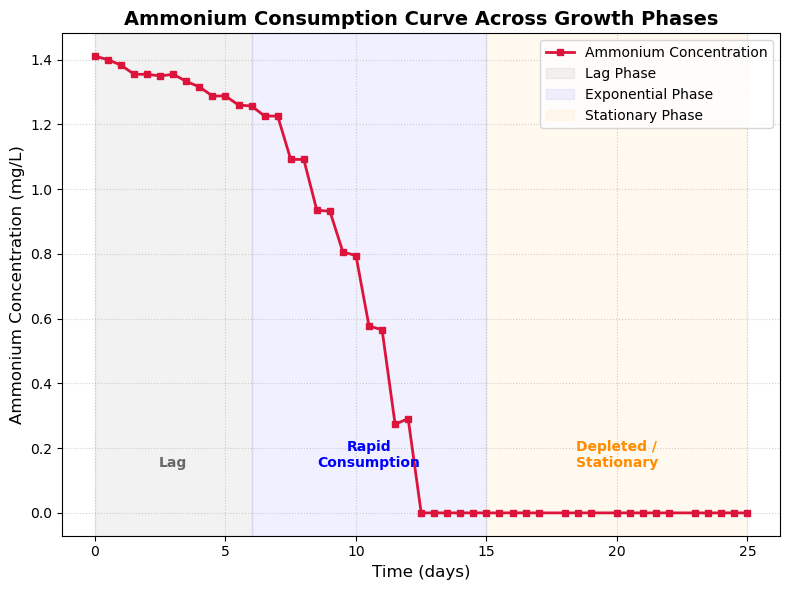

In [45]:


# . Phase Boundary Settings 
lag_end = 6.0
exp_end = 15.0
stat_end = 25.0

# Plotting Ammonium Consumption 
plt.figure(figsize=(8, 6))
plt.plot(
    time,
    ammonium,
    "s-",
    color="crimson",
    label="Ammonium Concentration",
    linewidth=2,
    markersize=5,
)

# Add Shaded Background Regions 
plt.axvspan(0, lag_end, color="gray", alpha=0.1, label="Lag Phase")
plt.axvspan(
    lag_end, exp_end, color="blue", alpha=0.06, label="Exponential Phase"
)
plt.axvspan(
    exp_end, stat_end, color="orange", alpha=0.06, label="Stationary Phase"
)

#  Adding Labels inside the graph 
max_y = max(ammonium) if len(ammonium) > 0 else 1.5
plt.text(
    lag_end / 2,
    max_y * 0.1,
    "Lag",
    ha="center",
    fontweight="bold",
    color="dimgray",
)
plt.text(
    (lag_end + exp_end) / 2,
    max_y * 0.1,
    "Rapid\nConsumption",
    ha="center",
    fontweight="bold",
    color="blue",
)
plt.text(
    (exp_end + stat_end) / 2,
    max_y * 0.1,
    "Depleted /\nStationary",
    ha="center",
    fontweight="bold",
    color="darkorange",
)

#  Graph Customization
plt.xlabel("Time (days)", fontsize=12)
plt.ylabel("Ammonium Concentration (mg/L)", fontsize=12)
plt.title("Ammonium Consumption Curve Across Growth Phases", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

### Estimate the parameters of the growth curve
The first step is to choose a model or improve this model that will assist to estimate the parameters of the growth curve by introducting a non-linear model 

In [ ]:
#AI decleration